# Tarea M32-AD – JORGE EDUARDO RUIZ GAYTAN

## Visualización y análisis de jugadores FIFA

En este notebook se realizará un análisis visual del dataset FIFA
mediante diferentes técnicas de visualización de datos.

El reporte estará compuesto por cinco elementos:

1. Matriz de correlación mediante heatmap.
2. Relación entre edad y Overall.
3. Número de jugadores por club.
4. Relación entre altura y Skill Moves según el pie preferido.
5. Análisis de jugadores con alto potencial.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ruta = r"C:\Users\jorge\OneDrive\Escritorio\TAREAM28\fifa_eda.csv"

df_fifa = pd.read_csv(ruta)

df_fifa.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


## Exploración inicial

Se visualiza una muestra aleatoria de 20 registros del dataset.

In [3]:
df_fifa.sample(20)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
6847,211514,R. James,24,England,68,72,Sunderland,975.0,5.0,Left,1.0,3.0,LB,2018,2019-01-01,5.583333,157.0,1800.000000
2639,223248,J. Lucero,26,Argentina,73,74,Club Tijuana,4800.0,19.0,Right,1.0,3.0,ST,2017,2019-01-01,5.833333,159.0,8500.000000
3350,236076,Marlion Simões,26,Brazil,72,72,Ceará Sporting Club,2600.0,14.0,Left,1.0,3.0,LB,2018,2021-01-01,5.916667,165.0,4900.000000
14640,243704,M. Knudsen,23,Denmark,61,68,Vendsyssel FF,350.0,2.0,Right,1.0,2.0,RCM,2018,2021-01-01,5.833333,154.0,508.000000
5841,232505,T. Hayashi,35,Japan,69,69,Sanfrecce Hiroshima,250.0,3.0,Right,1.0,1.0,GK,2014,2021-01-01,6.166667,192.0,313.000000
15224,244452,U. Tezel,21,Germany,60,69,SC Preußen Münster,280.0,1.0,Right,1.0,3.0,RB,2018,2020-01-01,5.916667,165.0,462.000000
16811,240749,J. Castillo,19,Chile,56,73,Deportes Iquique,190.0,1.0,Left,1.0,2.0,LW,2017,2018-01-01,5.416667,123.0,375.000000
17354,242240,L. D'Arrigo,16,Australia,54,71,Adelaide United,130.0,1.0,Right,1.0,2.0,CAM,2018,2019-01-01,5.750000,154.0,244.000000
3664,201363,R. Matos,25,Brazil,72,75,Hellas Verona,3900.0,19.0,Right,1.0,3.0,RW,2016,2019-06-30,6.000000,174.0,4585.060806
4100,201514,E. Kachunga,26,DR Congo,71,72,Huddersfield Town,2800.0,28.0,Right,1.0,3.0,RM,2016,2020-01-01,5.833333,163.0,5500.000000


In [4]:
columnas_correlacion = [
    "Age",
    "Overall",
    "Potential",
    "Skill Moves",
    "International Reputation"
]

matriz_correlacion = df_fifa[columnas_correlacion].corr()

matriz_correlacion

,Age,Overall,Potential,Skill Moves,International Reputation
Age,1.000000,0.452350,-0.253312,0.027649,0.253765
Overall,0.452350,1.000000,0.660939,0.414463,0.499491
Potential,-0.253312,0.660939,1.000000,0.354290,0.372993
Skill Moves,0.027649,0.414463,0.354290,1.000000,0.208153
International Reputation,0.253765,0.499491,0.372993,0.208153,1.000000


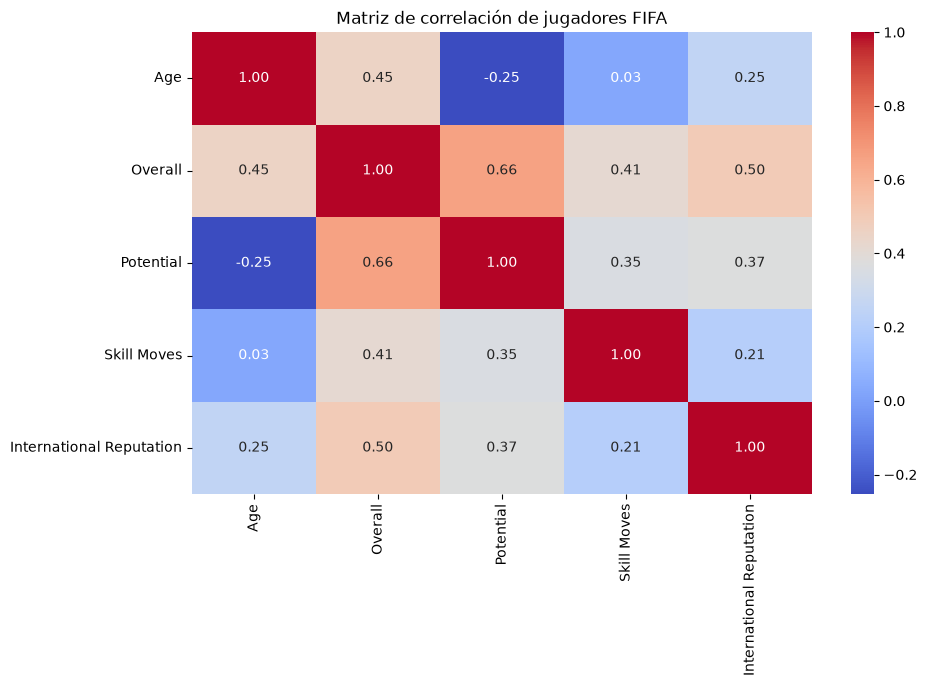

In [5]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matriz de correlación de jugadores FIFA")

plt.show()

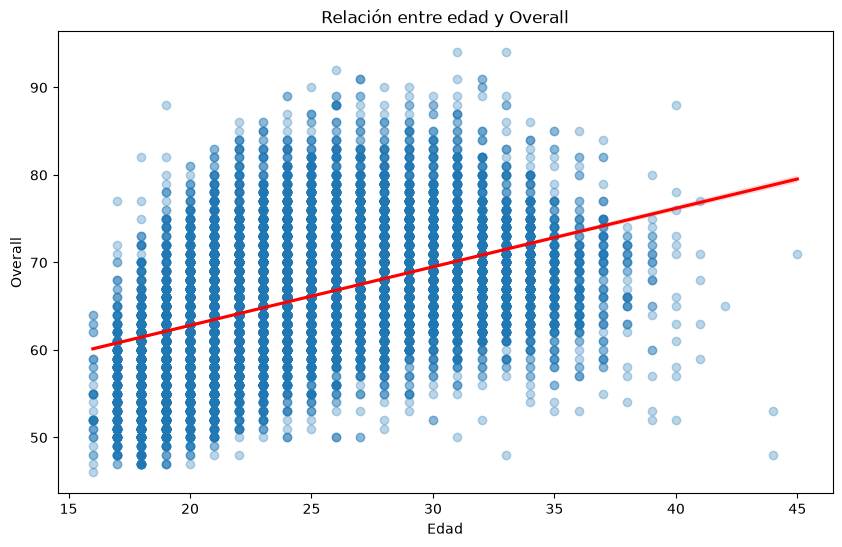

In [6]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_fifa,
    x="Age",
    y="Overall",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Relación entre edad y Overall")
plt.xlabel("Edad")
plt.ylabel("Overall")

plt.show()

In [7]:
correlacion_edad_overall = df_fifa["Age"].corr(
    df_fifa["Overall"]
)

print("Correlación entre Age y Overall:", correlacion_edad_overall)

Correlación entre Age y Overall: 0.45234952145633556


### Interpretación

El gráfico de dispersión permite analizar la relación entre la edad de
los jugadores y su valoración general (Overall).

La línea de tendencia permite identificar si existe una relación positiva
o negativa entre ambas variables. El coeficiente de correlación permite
medir la intensidad de esta relación.

Una correlación positiva indica que, en términos generales, el Overall
tiende a aumentar cuando aumenta la edad. Sin embargo, la dispersión de
los puntos demuestra que la edad por sí sola no determina la valoración
de un jugador.

In [8]:
jugadores_club = (
    df_fifa["Club"]
    .value_counts()
    .head(20)
)

jugadores_club

Club
FC Barcelona               33
Manchester United          33
Manchester City            33
Chelsea                    33
Real Madrid                33
Atlético Madrid            33
Tottenham Hotspur          33
Liverpool                  33
Arsenal                    33
Borussia Dortmund          33
Valencia CF                33
RC Celta                   33
AS Monaco                  33
Everton                    33
TSG 1899 Hoffenheim        33
Wolverhampton Wanderers    33
Eintracht Frankfurt        33
Burnley                    33
Southampton                33
Newcastle United           33
Name: count, dtype: int64

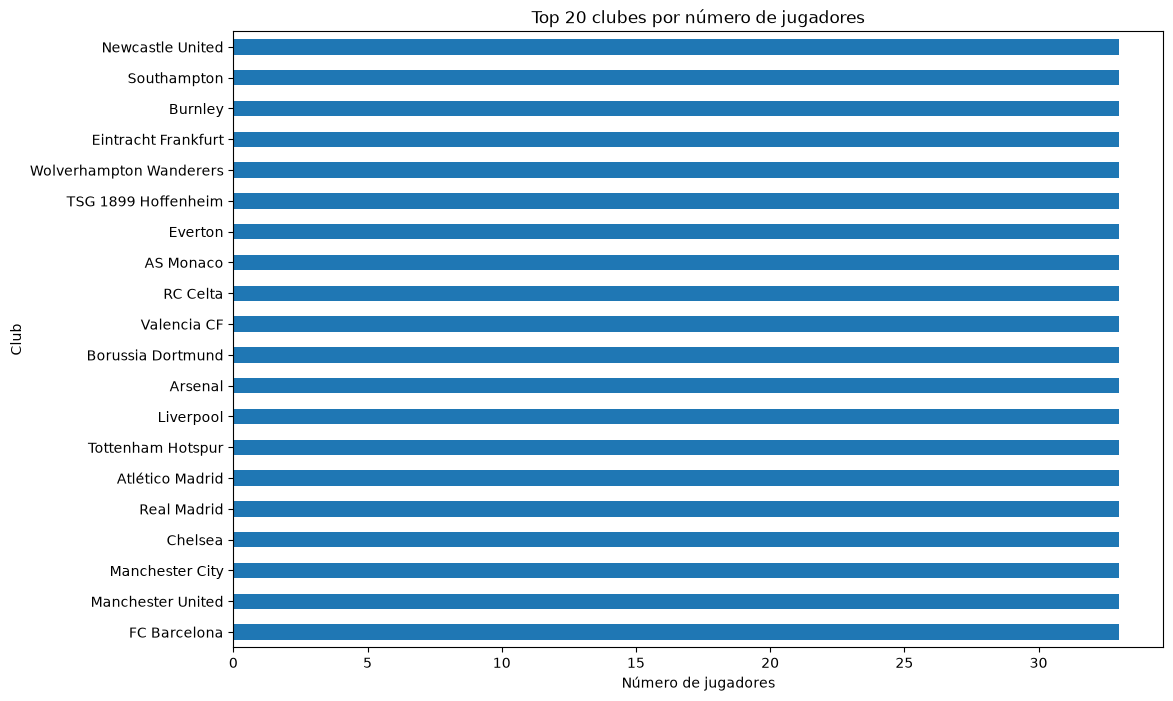

In [9]:
plt.figure(figsize=(12, 8))

jugadores_club.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 clubes por número de jugadores")
plt.xlabel("Número de jugadores")
plt.ylabel("Club")

plt.show()

In [10]:
df_fifa[
    ["Height", "Skill Moves", "Preferred Foot"]
].head(10)

,Height,Skill Moves,Preferred Foot
0,5.583333,4.0,Left
1,6.166667,5.0,Right
2,5.750000,5.0,Right
3,6.333333,1.0,Right
4,5.916667,4.0,Right
5,5.666667,4.0,Right
6,5.666667,4.0,Right
7,6.000000,3.0,Right
8,6.000000,3.0,Right
9,6.166667,1.0,Right


In [11]:
def altura_cm(altura):
    try:
        pies, pulgadas = altura.split("'")
        return int(pies) * 30.48 + int(pulgadas) * 2.54
    except:
        return None

In [12]:
df_fifa["Height_cm"] = df_fifa["Height"].apply(altura_cm)

In [13]:
df_fifa[
    ["Height", "Height_cm", "Skill Moves", "Preferred Foot"]
].head(10)

,Height,Height_cm,Skill Moves,Preferred Foot
0,5.583333,None,4.0,Left
1,6.166667,None,5.0,Right
2,5.750000,None,5.0,Right
3,6.333333,None,1.0,Right
4,5.916667,None,4.0,Right
5,5.666667,None,4.0,Right
6,5.666667,None,4.0,Right
7,6.000000,None,3.0,Right
8,6.000000,None,3.0,Right
9,6.166667,None,1.0,Right


In [15]:
potenciales_cracks = df_fifa[
    (df_fifa["Age"] <= 23) &
    (df_fifa["Potential"] >= 85)
].copy()

potenciales_cracks[
    ["Name", "Age", "Overall", "Potential", "Club"]
].sort_values(
    by="Potential",
    ascending=False
).head(20)

,Name,Age,Overall,Potential,Club
25,K. Mbappé,19,88,95,Paris Saint-Germain
229,G. Donnarumma,19,82,93,Milan
79,Marco Asensio,22,85,92,Real Madrid
55,L. Sané,22,86,92,Manchester City
156,Gabriel Jesus,21,83,92,Manchester City
155,O. Dembélé,21,83,92,FC Barcelona
77,M. Škriniar,23,85,92,Inter
1143,Vinícius Júnior,17,77,92,Real Madrid
177,Kepa,23,83,91,Chelsea
226,M. de Ligt,18,82,91,Ajax


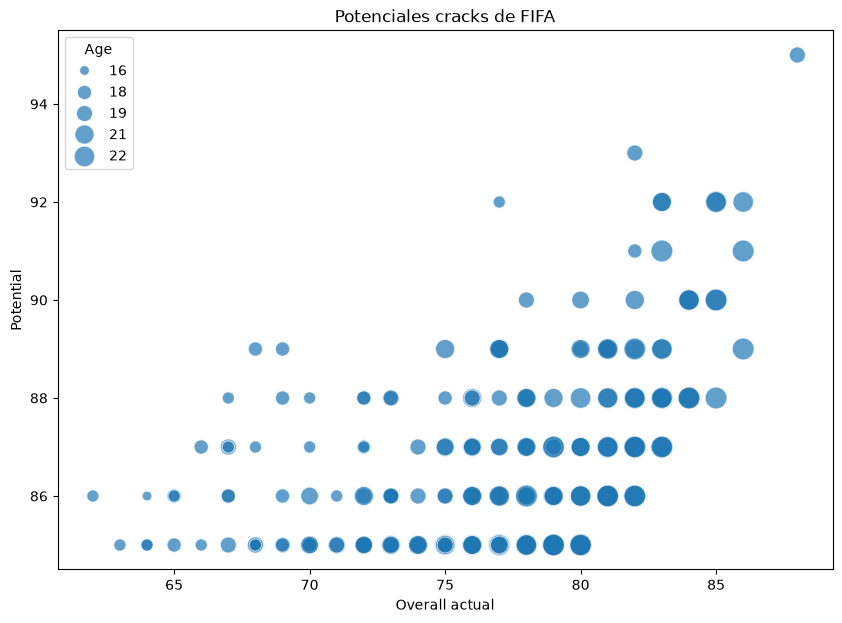

In [16]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=potenciales_cracks,
    x="Overall",
    y="Potential",
    size="Age",
    sizes=(50, 250),
    alpha=0.7
)

plt.title("Potenciales cracks de FIFA")
plt.xlabel("Overall actual")
plt.ylabel("Potential")

plt.show()

In [17]:
top_cracks = (
    potenciales_cracks
    .sort_values("Potential", ascending=False)
    .head(15)
)

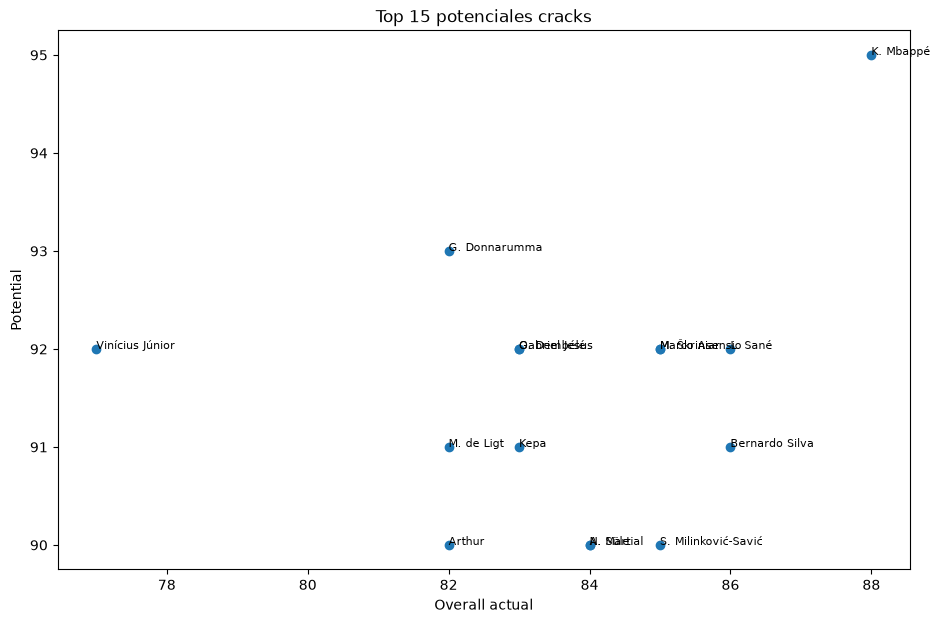

In [18]:
plt.figure(figsize=(11, 7))

plt.scatter(
    top_cracks["Overall"],
    top_cracks["Potential"]
)

for _, jugador in top_cracks.iterrows():
    plt.annotate(
        jugador["Name"],
        (jugador["Overall"], jugador["Potential"]),
        fontsize=8
    )

plt.title("Top 15 potenciales cracks")
plt.xlabel("Overall actual")
plt.ylabel("Potential")

plt.show()